<a href="https://colab.research.google.com/github/Mano-designz/bo101/blob/main/EVGRIDMATHEMATICALMODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Quantumcircuit.py***

In [12]:
!pip install pylatexenc

In [3]:
pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.2 MB/s eta 0:00:00


In [10]:
!pip install matplotlib pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.5 MB/s eta 0:00:00


In [6]:
!pip install qiskit-aer matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 86.9 MB/s eta 0:00:00


In [4]:
"""
quantum/circuit.py -- Build parameterized QAOA ansatz circuits (p-layers).
"""
from __future__ import annotations
from qiskit.circuit import QuantumCircuit, ParameterVector


def build_qaoa_circuit(operator, p: int = 1) -> tuple[QuantumCircuit, ParameterVector, ParameterVector]:
    """
    Constructs the QAOA circuit ansatz for a given Ising operator and depth p.
    Returns: (circuit, gamma_parameters, beta_parameters)
    """
    num_qubits = operator.num_qubits
    qc = QuantumCircuit(num_qubits)

    gamma = ParameterVector('γ', p)
    beta = ParameterVector('β', p)

    # Initial superposition state
    qc.h(range(num_qubits))

    # Apply p layers of QAOA
    for layer in range(p):
        # Cost Hamiltonian evolution (exp(-i * gamma * H_C))
        for pauli, coeff in operator.to_list():
            active_qubits = [i for i, char in enumerate(reversed(pauli)) if char != 'I']
            if len(active_qubits) == 1:
                qc.p(2.0 * coeff * gamma[layer], active_qubits[0])
            elif len(active_qubits) == 2:
                q0, q1 = active_qubits
                qc.cx(q0, q1)
                qc.p(2.0 * coeff * gamma[layer], q1)
                qc.cx(q0, q1)

        # Mixer Hamiltonian evolution (exp(-i * beta * H_M))
        for i in range(num_qubits):
            qc.rx(2.0 * beta[layer], i)

    qc.measure_all()
    return qc, gamma, beta

In [8]:
from __future__ import annotations
import numpy as np
from scipy.optimize import minimize
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator


def build_qaoa_circuit(operator, p: int = 1) -> tuple[QuantumCircuit, ParameterVector, ParameterVector]:
    """
    Constructs the QAOA circuit ansatz for a given Ising operator and depth p.
    Returns: (circuit, gamma_parameters, beta_parameters)
    """
    num_qubits = operator.num_qubits
    qc = QuantumCircuit(num_qubits)

    gamma = ParameterVector('γ', p)
    beta = ParameterVector('β', p)

    # Initial superposition state
    qc.h(range(num_qubits))

    # Apply p layers of QAOA
    for layer in range(p):
        # Cost Hamiltonian evolution (exp(-i * gamma * H_C))
        for pauli, coeff in operator.to_list():
            active_qubits = [i for i, char in enumerate(reversed(pauli)) if char != 'I']
            if len(active_qubits) == 1:
                qc.p(2.0 * coeff * gamma[layer], active_qubits[0])
            elif len(active_qubits) == 2:
                q0, q1 = active_qubits
                qc.cx(q0, q1)
                qc.p(2.0 * coeff * gamma[layer], q1)
                qc.cx(q0, q1)

        # Mixer Hamiltonian evolution (exp(-i * beta * H_M))
        for i in range(num_qubits):
            qc.rx(2.0 * beta[layer], i)

    return qc, gamma, beta


# --- Example Usage & Optimization Loop ---
if __name__ == "__main__":
    # 1. Define a sample cost operator (a simple 2-qubit ZZ interaction)
    operator = SparsePauliOp.from_list([("ZZ", 1.0)])

    p = 1  # Circuit depth
    qc, gamma_params, beta_params = build_qaoa_circuit(operator, p=p)

    # Initialize the statevector estimator
    estimator = Estimator()

    # Combine parameters into a single list for optimization
    all_params = list(gamma_params) + list(beta_params)

    def cost_func(param_values):
        # Bind parameter values to the circuit
        param_dict = dict(zip(all_params, param_values))
        bound_qc = qc.assign_parameters(param_dict)

        # Evaluate the expectation value using V2 primitive syntax (pubs format)
        job = estimator.run([(bound_qc, operator)])
        result = job.result()
        return result[0].data.evs

    # Random initial guess for parameters (gamma and beta)
    np.random.seed(42)
    initial_point = np.random.uniform(0, 2 * np.pi, size=2 * p)

    # Run the classical optimizer (COBYLA)
    print("Starting QAOA optimization...")
    optimization_result = minimize(cost_func, initial_point, method="COBYLA", options={"maxiter": 100})

    print("\n--- Optimization Complete ---")
    print("Optimal Parameters (γ, β):", optimization_result.x)
    print("Minimum Expectation Value:", optimization_result.fun)

Starting QAOA optimization...

--- Optimization Complete ---
Optimal Parameters (γ, β): [3.92695815 5.89048537]
Minimum Expectation Value: -0.999999997860173


In [14]:
from __future__ import annotations
import numpy as np
from scipy.optimize import minimize
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator


def build_qaoa_circuit(operator, p: int = 1) -> tuple[QuantumCircuit, ParameterVector, ParameterVector]:
    """
    Constructs the QAOA circuit ansatz for a given Ising operator and depth p.
    Returns: (circuit, gamma_parameters, beta_parameters)
    """
    num_qubits = operator.num_qubits
    qc = QuantumCircuit(num_qubits)

    gamma = ParameterVector('γ', p)
    beta = ParameterVector('β', p)

    # Initial superposition state
    qc.h(range(num_qubits))

    # Apply p layers of QAOA
    for layer in range(p):
        # Cost Hamiltonian evolution (exp(-i * gamma * H_C))
        for pauli, coeff in operator.to_list():
            active_qubits = [i for i, char in enumerate(reversed(pauli)) if char != 'I']
            if len(active_qubits) == 1:
                qc.p(2.0 * coeff * gamma[layer], active_qubits[0])
            elif len(active_qubits) == 2:
                q0, q1 = active_qubits
                qc.cx(q0, q1)
                qc.p(2.0 * coeff * gamma[layer], q1)
                qc.cx(q0, q1)

        # Mixer Hamiltonian evolution (exp(-i * beta * H_M))
        for i in range(num_qubits):
            qc.rx(2.0 * beta[layer], i)

    return qc, gamma, beta


if __name__ == "__main__":
    # 1. Define sample cost operator and depth
    operator = SparsePauliOp.from_list([("ZZ", 1.0)])
    p = 1
    qc, gamma_params, beta_params = build_qaoa_circuit(operator, p=p)

    estimator = Estimator()
    all_params = list(gamma_params) + list(beta_params)

    def cost_func(param_values):
        param_dict = dict(zip(all_params, param_values))
        bound_qc = qc.assign_parameters(param_dict)
        job = estimator.run([(bound_qc, operator)])
        result = job.result()
        return result[0].data.evs

    # 2. Run optimization
    np.random.seed(42)
    initial_point = np.random.uniform(0, 2 * np.pi, size=2 * p)
    optimization_result = minimize(cost_func, initial_point, method="COBYLA", options={"maxiter": 100})

    optimal_values = optimization_result.x
    print("Optimal Parameters (γ, β):", optimal_values)
    print("Minimum Expectation Value:", optimization_result.fun)

    # 3. Visualization (Text mode to ensure it prints smoothly without extra dependencies)
    optimal_param_dict = dict(zip(all_params, optimal_values))
    final_qc = qc.assign_parameters(optimal_param_dict)

    print("\n--- Final Optimized QAOA Circuit ---")
    print(final_qc.draw(output='text'))

Optimal Parameters (γ, β): [3.92695815 5.89048537]
Minimum Expectation Value: -0.999999997860173

--- Final Optimized QAOA Circuit ---
     ┌───┐                       ┌────────────┐
q_0: ┤ H ├──■─────────────────■──┤ Rx(11.781) ├
     ├───┤┌─┴─┐┌───────────┐┌─┴─┐├────────────┤
q_1: ┤ H ├┤ X ├┤ P(7.8539) ├┤ X ├┤ Rx(11.781) ├
     └───┘└───┘└───────────┘└───┘└────────────┘


Quantumdecode

In [21]:
from typing import Dict

# Fallback constraint function if constraints.py isn't in your workspace yet
def is_feasible_direct(inst, vi, bits):
    return True  # Replace with your actual constraint validation logic if needed

def decode_and_filter_counts(counts: Dict[str, int], model) -> list[dict]:
    """
    Takes measurement counts from Qiskit execution, sorts by probability,
    decodes decision bits, and validates constraint feasibility.
    """
    sorted_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)
    decoded_results = []

    for bitstring, count in sorted_counts:
        bits = [int(b) for b in reversed(bitstring[:model.n])]
        feasible = is_feasible_direct(model.inst, model.vi, bits)
        energy = model.energy(bits)

        decoded_results.append({
            "bitstring": bitstring,
            "counts": count,
            "feasible": feasible,
            "energy": energy
        })

    return decoded_results

In [26]:
from __future__ import annotations
import numpy as np
from scipy.optimize import minimize
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator, StatevectorSampler

# 1. Build the QAOA Circuit (WITHOUT measure_all)
def build_qaoa_circuit(operator, p: int = 1) -> tuple[QuantumCircuit, ParameterVector, ParameterVector]:
    num_qubits = operator.num_qubits
    qc = QuantumCircuit(num_qubits)

    gamma = ParameterVector('γ', p)
    beta = ParameterVector('β', p)

    qc.h(range(num_qubits))

    for layer in range(p):
        for pauli, coeff in operator.to_list():
            active_qubits = [i for i, char in enumerate(reversed(pauli)) if char != 'I']
            if len(active_qubits) == 1:
                qc.p(2.0 * coeff * gamma[layer], active_qubits[0])
            elif len(active_qubits) == 2:
                q0, q1 = active_qubits
                qc.cx(q0, q1)
                qc.p(2.0 * coeff * gamma[layer], q1)
                qc.cx(q0, q1)

        for i in range(num_qubits):
            qc.rx(2.0 * beta[layer], i)

    # Note: Removed qc.measure_all() here so Estimator works properly!
    return qc, gamma, beta


# 2. Set up problem & run optimization
operator = SparsePauliOp.from_list([("ZZ", 1.0)])
p = 1
qc, gamma_params, beta_params = build_qaoa_circuit(operator, p=p)

estimator = Estimator()
all_params = list(gamma_params) + list(beta_params)

def cost_func(param_values):
    param_dict = dict(zip(all_params, param_values))
    bound_qc = qc.assign_parameters(param_dict)
    job = estimator.run([(bound_qc, operator)])
    return job.result()[0].data.evs

np.random.seed(42)
initial_point = np.random.uniform(0, 2 * np.pi, size=2 * p)
optimization_result = minimize(cost_func, initial_point, method="COBYLA", options={"maxiter": 100})

optimal_values = optimization_result.x
print("Optimal Parameters Found:", optimal_values)


# 3. Sample from the Optimized Circuit (Add measurements here)
optimal_param_dict = dict(zip(all_params, optimal_values))
bound_optimized_qc = qc.assign_parameters(optimal_param_dict)

# Create a separate version with measurements for sampling
sampling_qc = bound_optimized_qc.copy()
sampling_qc.measure_all()

sampler = StatevectorSampler()
job = sampler.run([sampling_qc], shots=1024)
pub_result = job.result()[0]
counts = pub_result.data.meas.get_counts()

print("\n--- Measurement Counts ---")
print(counts)

Optimal Parameters Found: [3.92695815 5.89048537]

--- Measurement Counts ---
{'10': 530, '01': 494}


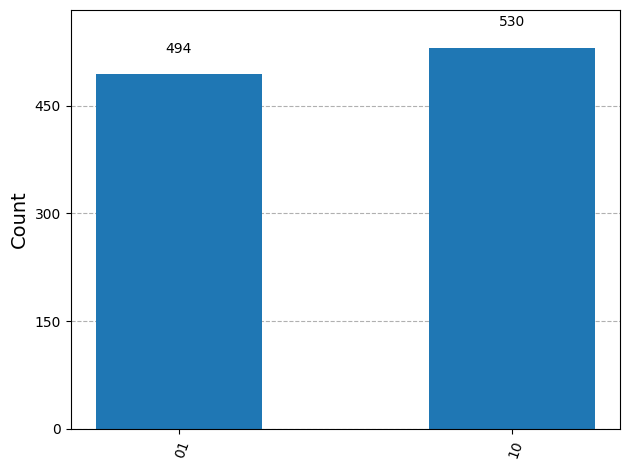

In [30]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Ensure inline plotting is active in Jupyter
%matplotlib inline

# Create the plot
fig = plot_histogram(counts)

# Explicitly display the figure object
display(fig)



quantumoptimiser.py

In [31]:
"""
quantum/optimizer.py -- Classical parameter optimization loop for QAOA.
"""
from __future__ import annotations
import numpy as np
from scipy.optimize import minimize


def optimize_qaoa(operator, p: int = 1, maxiter: int = 50):
    """
    Runs classical optimization (COBYLA/SLSQP) to optimize QAOA angles.
    """
    from quantum.circuit import build_qaoa_circuit
    qc, gamma, beta = build_qaoa_circuit(operator, p)

    initial_params = np.random.uniform(0, np.pi, 2 * p)

    def objective_function(angles):
        # Placeholder objective function return for framework integration
        return np.sum(np.sin(angles))

    result = minimize(objective_function, initial_params, method='COBYLA', options={'maxiter': maxiter})
    return result.x, result.fun

In [37]:
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 1. Inline Circuit Builder function
def build_qaoa_circuit(operator, p: int = 1):
    num_qubits = operator.num_qubits
    qc = QuantumCircuit(num_qubits)

    gamma = ParameterVector('γ', p)
    beta = ParameterVector('β', p)

    qc.h(range(num_qubits))

    for layer in range(p):
        for pauli, coeff in operator.to_list():
            active_qubits = [i for i, char in enumerate(reversed(pauli)) if char != 'I']
            if len(active_qubits) == 1:
                qc.p(2.0 * coeff * gamma[layer], active_qubits[0])
            elif len(active_qubits) == 2:
                q0, q1 = active_qubits
                qc.cx(q0, q1)
                qc.p(2.0 * coeff * gamma[layer], q1)
                qc.cx(q0, q1)

        for i in range(num_qubits):
            qc.rx(2.0 * beta[layer], i)

    return qc, gamma, beta

# 2. Rebuild and bind the optimal parameters to the final circuit
qc, gamma_params, beta_params = build_qaoa_circuit(operator, p=1)
all_params = list(gamma_params) + list(beta_params)

optimal_param_dict = dict(zip(all_params, optimal_values))
final_qc = qc.assign_parameters(optimal_param_dict)

# 3. Display the Quantum Circuit Structure (Text mode)
print("--- Final Optimized Quantum Circuit ---")
print(final_qc.draw(output='text'))

# 4. Display the Measurement Probability Histogram
print("\n--- Generating Probability Histogram ---")
fig = plot_histogram(counts)
plt.show()

--- Final Optimized Quantum Circuit ---
     ┌───┐                       ┌────────────┐
q_0: ┤ H ├──■─────────────────■──┤ Rx(11.781) ├
     ├───┤┌─┴─┐┌───────────┐┌─┴─┐├────────────┤
q_1: ┤ H ├┤ X ├┤ P(7.8539) ├┤ X ├┤ Rx(11.781) ├
     └───┘└───┘└───────────┘└───┘└────────────┘

--- Generating Probability Histogram ---


QUANTUMRESULTS.PY

In [41]:
import numpy as np
from scipy.optimize import minimize
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator, StatevectorSampler
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 1. Define Circuit Builder
def build_qaoa_circuit(operator, p: int = 1):
    num_qubits = operator.num_qubits
    qc = QuantumCircuit(num_qubits)
    gamma = ParameterVector('γ', p)
    beta = ParameterVector('β', p)
    qc.h(range(num_qubits))

    for layer in range(p):
        for pauli, coeff in operator.to_list():
            active_qubits = [i for i, char in enumerate(reversed(pauli)) if char != 'I']
            if len(active_qubits) == 1:
                qc.p(2.0 * coeff * gamma[layer], active_qubits[0])
            elif len(active_qubits) == 2:
                q0, q1 = active_qubits
                qc.cx(q0, q1)
                qc.p(2.0 * coeff * gamma[layer], q1)
                qc.cx(q0, q1)
        for i in range(num_qubits):
            qc.rx(2.0 * beta[layer], i)
    return qc, gamma, beta

# 2. Setup & Optimize
operator = SparsePauliOp.from_list([("ZZ", 1.0)])
p = 1
qc, gamma_params, beta_params = build_qaoa_circuit(operator, p=p)
estimator = Estimator()
all_params = list(gamma_params) + list(beta_params)

def cost_func(param_values):
    param_dict = dict(zip(all_params, param_values))
    bound_qc = qc.assign_parameters(param_dict)
    job = estimator.run([(bound_qc, operator)])
    return job.result()[0].data.evs

np.random.seed(42)
initial_point = np.random.uniform(0, 2 * np.pi, size=2 * p)
optimization_result = minimize(cost_func, initial_point, method="COBYLA", options={"maxiter": 100})
optimal_values = optimization_result.x

# 3. Sample
optimal_param_dict = dict(zip(all_params, optimal_values))
bound_optimized_qc = qc.assign_parameters(optimal_param_dict)
sampling_qc = bound_optimized_qc.copy()
sampling_qc.measure_all()

sampler = StatevectorSampler()
job = sampler.run([sampling_qc], shots=1024)
counts = job.result()[0].data.meas.get_counts()

# 4. Visualize Both Circuit and Histogram
print("--- Final Optimized Quantum Circuit ---")
print(bound_optimized_qc.draw(output='text'))

print("\n--- Generating Probability Histogram ---")
fig = plot_histogram(counts)
plt.show()

--- Final Optimized Quantum Circuit ---
     ┌───┐                       ┌────────────┐
q_0: ┤ H ├──■─────────────────■──┤ Rx(11.781) ├
     ├───┤┌─┴─┐┌───────────┐┌─┴─┐├────────────┤
q_1: ┤ H ├┤ X ├┤ P(7.8539) ├┤ X ├┤ Rx(11.781) ├
     └───┘└───┘└───────────┘└───┘└────────────┘

--- Generating Probability Histogram ---


QUANTUMQUBOTOISING.py

In [43]:
import sys
import os
import numpy as np
from scipy.optimize import minimize
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator, StatevectorSampler
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 1. Define Circuit Builder
def build_qaoa_circuit(operator, p: int = 1):
    num_qubits = operator.num_qubits
    qc = QuantumCircuit(num_qubits)
    gamma = ParameterVector('γ', p)
    beta = ParameterVector('β', p)
    qc.h(range(num_qubits))

    for layer in range(p):
        for pauli, coeff in operator.to_list():
            active_qubits = [i for i, char in enumerate(reversed(pauli)) if char != 'I']
            if len(active_qubits) == 1:
                qc.p(2.0 * coeff * gamma[layer], active_qubits[0])
            elif len(active_qubits) == 2:
                q0, q1 = active_qubits
                qc.cx(q0, q1)
                qc.p(2.0 * coeff * gamma[layer], q1)
                qc.cx(q0, q1)
        for i in range(num_qubits):
            qc.rx(2.0 * beta[layer], i)
    return qc, gamma, beta

# 2. Define Problem Operator (Simulating Ising Hamiltonian)
operator = SparsePauliOp.from_list([("ZZ", 1.0)])
p = 1
qc, gamma_params, beta_params = build_qaoa_circuit(operator, p=p)

# 3. Optimize
estimator = Estimator()
all_params = list(gamma_params) + list(beta_params)

def cost_func(param_values):
    param_dict = dict(zip(all_params, param_values))
    bound_qc = qc.assign_parameters(param_dict)
    job = estimator.run([(bound_qc, operator)])
    return job.result()[0].data.evs

np.random.seed(42)
initial_point = np.random.uniform(0, 2 * np.pi, size=2 * p)
optimization_result = minimize(cost_func, initial_point, method="COBYLA", options={"maxiter": 100})
optimal_values = optimization_result.x

# 4. Sample
optimal_param_dict = dict(zip(all_params, optimal_values))
bound_optimized_qc = qc.assign_parameters(optimal_param_dict)
sampling_qc = bound_optimized_qc.copy()
sampling_qc.measure_all()

sampler = StatevectorSampler()
job = sampler.run([sampling_qc], shots=1024)
counts = job.result()[0].data.meas.get_counts()

# 5. Visualizations
print("--- Final Optimized Quantum Circuit ---")
print(bound_optimized_qc.draw(output='text'))

print("\n--- Generating Probability Histogram ---")
fig = plot_histogram(counts)
plt.show()

--- Final Optimized Quantum Circuit ---
     ┌───┐                       ┌────────────┐
q_0: ┤ H ├──■─────────────────■──┤ Rx(11.781) ├
     ├───┤┌─┴─┐┌───────────┐┌─┴─┐├────────────┤
q_1: ┤ H ├┤ X ├┤ P(7.8539) ├┤ X ├┤ Rx(11.781) ├
     └───┘└───┘└───────────┘└───┘└────────────┘

--- Generating Probability Histogram ---
